# Multi-class MitUNet training

This notebook trains MitUNet with one output channel per class. Masks are integer labels: `0` is background and `1..N` are the semantic classes from `ResPlanSegmentationDataset`.


In [1]:
import json
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

try:
    import albumentations as A
except ImportError:
    A = None

import segmentation_models_pytorch as smp
from shapely import affinity
from shapely.errors import GEOSException
from shapely.geometry.base import BaseGeometry

try:
    from shapely import make_valid
except ImportError:
    from shapely.validation import make_valid

PROJECT_ROOT = Path("/home/ubuntu/mitunet")
sys.path.insert(0, str(PROJECT_ROOT))

import src.data_loader as data_loader
from src.data_loader import ResPlanSegmentationDataset
from src.model.model import build_mitunet

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
print(f"Running on: {DEVICE}")


/home/ubuntu/mitunet/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on: cuda


In [2]:
def _make_valid_geometry(geom):
    if not isinstance(geom, BaseGeometry) or geom.is_empty:
        return geom

    try:
        if geom.is_valid:
            return geom
        return make_valid(geom)
    except GEOSException:
        return geom.buffer(0)


def safe_fit_plan_to_canvas(plan, shape=(256, 256), padding=8):
    h, w = shape
    cleaned_plan = {}
    geoms = []

    for key, value in plan.items():
        if isinstance(value, BaseGeometry):
            value = _make_valid_geometry(value)
            cleaned_plan[key] = value
            if not value.is_empty:
                geoms.append(value)
        else:
            cleaned_plan[key] = value

    bounds = [geom.bounds for geom in geoms if len(geom.bounds) == 4]
    if not bounds:
        return cleaned_plan

    minx = min(bound[0] for bound in bounds)
    miny = min(bound[1] for bound in bounds)
    maxx = max(bound[2] for bound in bounds)
    maxy = max(bound[3] for bound in bounds)

    plan_w = max(maxx - minx, 1e-6)
    plan_h = max(maxy - miny, 1e-6)
    scale = min((w - 2 * padding) / plan_w, (h - 2 * padding) / plan_h)

    fitted = {}
    for key, value in cleaned_plan.items():
        if isinstance(value, BaseGeometry):
            if value.is_empty:
                fitted[key] = value
                continue
            geom = affinity.translate(value, xoff=-minx, yoff=-miny)
            geom = affinity.scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
            geom = affinity.translate(geom, xoff=padding, yoff=padding)
            fitted[key] = geom
        else:
            fitted[key] = value

    return fitted


# Patch only this notebook session. This avoids Shapely unary_union failures from invalid polygons
# without changing src/data_loader.py.
data_loader.fit_plan_to_canvas = safe_fit_plan_to_canvas
print("Using notebook-safe fit_plan_to_canvas for invalid geometries")


Using notebook-safe fit_plan_to_canvas for invalid geometries


In [3]:
PKL_PATH = PROJECT_ROOT / "ResPlan.pkl"
IMAGE_SIZE = (256, 256)
PADDING = 8
VALID_FRACTION = 0.2
BATCH_SIZE = 8
NUM_WORKERS = 0

ENCODER_NAME = "mit_b4"
IN_CHANNELS = 3
ENCODER_WEIGHTS = "imagenet"
WARM_START_CHECKPOINT = PROJECT_ROOT / "mitunet.pth"

EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
SAVE_DIR = PROJECT_ROOT / "outputs"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if A is not None:
    train_augment = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])
else:
    train_augment = None

base_dataset = ResPlanSegmentationDataset(
    pkl_path=str(PKL_PATH),
    shape=IMAGE_SIZE,
    padding=PADDING,
    augment=None,
)

num_samples = len(base_dataset)
valid_size = max(1, int(num_samples * VALID_FRACTION))
train_size = num_samples - valid_size
indices = torch.randperm(num_samples, generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices = indices[:train_size]
valid_indices = indices[train_size:]

train_base_dataset = ResPlanSegmentationDataset(
    pkl_path=str(PKL_PATH),
    shape=IMAGE_SIZE,
    classes=base_dataset.classes,
    padding=PADDING,
    augment=train_augment,
)
valid_base_dataset = ResPlanSegmentationDataset(
    pkl_path=str(PKL_PATH),
    shape=IMAGE_SIZE,
    classes=base_dataset.classes,
    padding=PADDING,
    augment=None,
)

train_dataset = Subset(train_base_dataset, train_indices)
valid_dataset = Subset(valid_base_dataset, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

NUM_CLASSES = base_dataset.num_classes
CLASS_NAMES = ["background"] + base_dataset.classes
IDX_TO_CLASS = {0: "background", **base_dataset.idx_to_class}

print("Classes:", CLASS_NAMES)
print("Class mapping:", {name: idx for idx, name in IDX_TO_CLASS.items()})
print("Num classes:", NUM_CLASSES)
print(f"Train samples: {len(train_dataset)} | Valid samples: {len(valid_dataset)}")

images, masks = next(iter(train_loader))
print("Images:", tuple(images.shape))
print("Masks:", tuple(masks.shape))
print("Mask labels:", torch.unique(masks).tolist())


Classes: ['background', 'living', 'bedroom', 'bathroom', 'kitchen', 'door', 'window', 'wall', 'front_door', 'balcony']
Class mapping: {'background': 0, 'living': 1, 'bedroom': 2, 'bathroom': 3, 'kitchen': 4, 'door': 5, 'window': 6, 'wall': 7, 'front_door': 8, 'balcony': 9}
Num classes: 10
Train samples: 13686 | Valid samples: 3421
Images: (8, 1, 256, 256)
Masks: (8, 256, 256)
Mask labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


/tmp/ipykernel_74105/2775698420.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


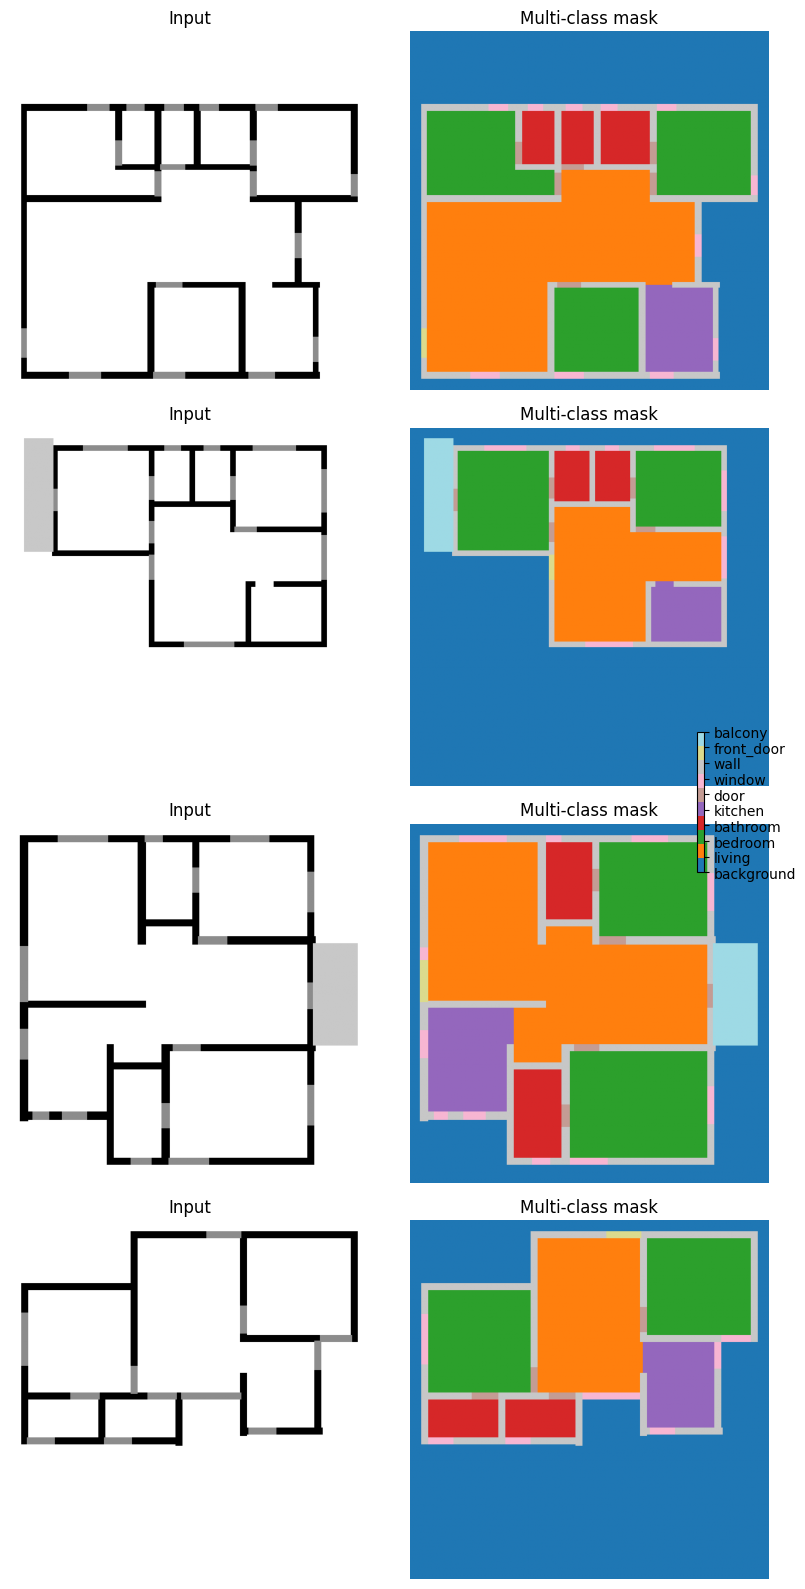

In [4]:
def show_batch(dataset, count=4):
    count = min(count, len(dataset))
    fig, axes = plt.subplots(count, 2, figsize=(8, 4 * count))
    if count == 1:
        axes = np.expand_dims(axes, axis=0)

    cmap = plt.get_cmap("tab20", NUM_CLASSES)
    for row in range(count):
        image, mask = dataset[row]
        axes[row, 0].imshow(image.squeeze(0), cmap="gray")
        axes[row, 0].set_title("Input")
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
        axes[row, 1].set_title("Multi-class mask")
        axes[row, 1].axis("off")

    cbar = fig.colorbar(im, ax=axes[:, 1], fraction=0.025, pad=0.02, ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)
    plt.tight_layout()
    plt.show()


show_batch(train_dataset, count=4)


In [5]:
def load_matching_weights(model, checkpoint_path, device=DEVICE):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        print(f"Warm-start checkpoint not found: {checkpoint_path}")
        return

    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        checkpoint = checkpoint["model_state_dict"]

    model_state = model.state_dict()
    compatible = {
        key: value
        for key, value in checkpoint.items()
        if key in model_state and model_state[key].shape == value.shape
    }

    model_state.update(compatible)
    model.load_state_dict(model_state)

    skipped = sorted(set(checkpoint) - set(compatible))
    print(f"Loaded {len(compatible)} tensors from {checkpoint_path.name}")
    print(f"Skipped {len(skipped)} tensors with missing keys or different shapes")


model = build_mitunet(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
    decoder_attention_type="scse",
    checkpoint_path=None,
    device=DEVICE,
)

load_matching_weights(model, WARM_START_CHECKPOINT, device=DEVICE)

ce_loss = nn.CrossEntropyLoss()
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)


def loss_fn(logits, masks):
    return ce_loss(logits, masks) + dice_loss(logits, masks)


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

print(f"Model output classes: {NUM_CLASSES}")
print(f"Training input channels: {IN_CHANNELS}")


/tmp/ipykernel_74105/2236456757.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Loaded 952 tensors from mitunet.pth
Skipped 2 tensors with missing keys or different shapes
Model output classes: 10
Training input channels: 3


In [6]:
def prepare_images(images):
    images = images.to(DEVICE, non_blocking=True)
    if images.shape[1] == IN_CHANNELS:
        return images
    if images.shape[1] == 1 and IN_CHANNELS == 3:
        return images.repeat(1, 3, 1, 1)
    raise ValueError(f"Dataset returned {images.shape[1]} channels, but model expects {IN_CHANNELS}")


def empty_stats():
    foreground_classes = max(NUM_CLASSES - 1, 1)
    return {
        "tp": torch.zeros(foreground_classes, dtype=torch.float64),
        "fp": torch.zeros(foreground_classes, dtype=torch.float64),
        "fn": torch.zeros(foreground_classes, dtype=torch.float64),
        "correct": 0,
        "pixels": 0,
    }


def update_stats(stats, logits, masks):
    preds = logits.argmax(dim=1)
    tp, fp, fn, _ = smp.metrics.get_stats(
        preds.detach().cpu(),
        masks.detach().cpu(),
        mode="multiclass",
        num_classes=NUM_CLASSES,
    )

    if NUM_CLASSES > 1:
        stats["tp"] += tp[:, 1:].sum(dim=0).double()
        stats["fp"] += fp[:, 1:].sum(dim=0).double()
        stats["fn"] += fn[:, 1:].sum(dim=0).double()
    else:
        stats["tp"] += tp.sum(dim=0).double()
        stats["fp"] += fp.sum(dim=0).double()
        stats["fn"] += fn.sum(dim=0).double()

    stats["correct"] += (preds == masks).sum().item()
    stats["pixels"] += masks.numel()


def summarize_stats(stats):
    eps = 1e-7
    tp, fp, fn = stats["tp"], stats["fp"], stats["fn"]
    union = tp + fp + fn
    valid = union > 0
    per_class_iou = torch.zeros_like(tp)
    per_class_iou[valid] = tp[valid] / (union[valid] + eps)

    micro_iou = tp.sum() / (union.sum() + eps)
    macro_iou = per_class_iou[valid].mean() if valid.any() else torch.tensor(0.0)
    precision = tp.sum() / (tp.sum() + fp.sum() + eps)
    recall = tp.sum() / (tp.sum() + fn.sum() + eps)
    pixel_accuracy = stats["correct"] / max(stats["pixels"], 1)

    return {
        "micro_iou": float(micro_iou),
        "macro_iou": float(macro_iou),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
        "per_class_iou": per_class_iou.numpy(),
    }


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_samples = 0
    stats = empty_stats()
    start = time.perf_counter()

    desc = "Training" if is_train else "Validation"
    pbar = tqdm(loader, desc=desc)

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, masks in pbar:
            images = prepare_images(images)
            masks = masks.to(DEVICE, non_blocking=True).long()

            logits = model(images)
            loss = loss_fn(logits, masks)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            update_stats(stats, logits, masks)

            scores = summarize_stats(stats)
            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                miou=f"{scores['micro_iou']:.4f}",
            )

    elapsed = time.perf_counter() - start
    scores = summarize_stats(stats)
    scores["loss"] = total_loss / max(total_samples, 1)
    scores["fps"] = total_samples / max(elapsed, 1e-7)
    return scores


In [7]:
best_model_path = SAVE_DIR / f"mitunet_{ENCODER_NAME}_multiclass_best.pth"
best_metadata_path = SAVE_DIR / f"mitunet_{ENCODER_NAME}_multiclass_best.json"
best_iou = -1.0
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_scores = run_epoch(model, train_loader, optimizer=optimizer)
    valid_scores = run_epoch(model, valid_loader, optimizer=None)
    lr_scheduler.step(valid_scores["micro_iou"])

    row = {
        "epoch": epoch,
        "train_loss": train_scores["loss"],
        "valid_loss": valid_scores["loss"],
        "train_micro_iou": train_scores["micro_iou"],
        "valid_micro_iou": valid_scores["micro_iou"],
        "train_macro_iou": train_scores["macro_iou"],
        "valid_macro_iou": valid_scores["macro_iou"],
        "valid_pixel_accuracy": valid_scores["pixel_accuracy"],
        "valid_fps": valid_scores["fps"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Train loss: {row['train_loss']:.4f} | Valid loss: {row['valid_loss']:.4f} | "
        f"Train mIoU: {row['train_micro_iou']:.4f} | Valid mIoU: {row['valid_micro_iou']:.4f} | "
        f"Valid macro IoU: {row['valid_macro_iou']:.4f} | LR: {row['lr']:.2e}"
    )

    if valid_scores["micro_iou"] > best_iou:
        best_iou = valid_scores["micro_iou"]
        torch.save(model.state_dict(), best_model_path)
        metadata = {
            "classes": CLASS_NAMES,
            "idx_to_class": IDX_TO_CLASS,
            "num_classes": NUM_CLASSES,
            "image_size": IMAGE_SIZE,
            "in_channels": IN_CHANNELS,
            "encoder_name": ENCODER_NAME,
            "epoch": epoch,
            "valid_micro_iou": best_iou,
            "valid_macro_iou": valid_scores["macro_iou"],
        }
        with open(best_metadata_path, "w") as f:
            json.dump(metadata, f, indent=2)
        print(f"Saved new best model to {best_model_path}")

print(f"\nTraining complete. Best validation micro IoU: {best_iou:.4f}")



Epoch 1/30


Validation: 100%|██████████| 428/428 [01:39<00:00,  4.30it/s, loss=0.1106, miou=0.9477]


Train loss: 0.4816 | Valid loss: 0.1247 | Train mIoU: 0.8204 | Valid mIoU: 0.9477 | Valid macro IoU: 0.9105 | LR: 1.00e-04
Saved new best model to /home/ubuntu/mitunet/outputs/mitunet_mit_b4_multiclass_best.pth

Epoch 2/30


Training:   4%|▍         | 74/1711 [00:42<15:47,  1.73it/s, loss=0.1778, miou=0.9539]


KeyboardInterrupt: 

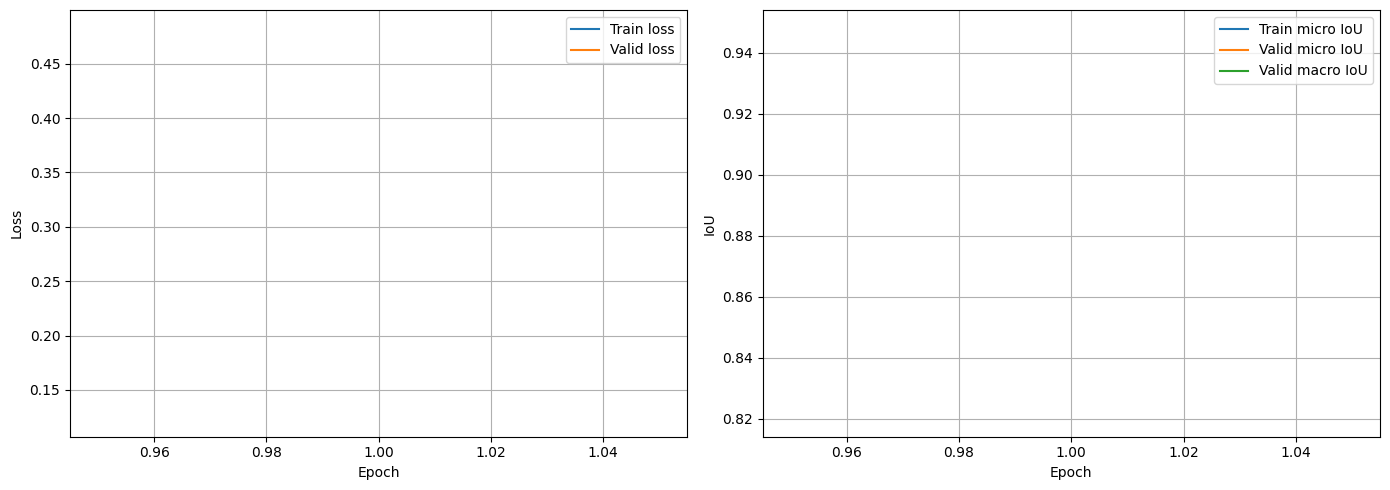

In [8]:
if history:
    epochs = [row["epoch"] for row in history]

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, [row["train_loss"] for row in history], label="Train loss")
    plt.plot(epochs, [row["valid_loss"] for row in history], label="Valid loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, [row["train_micro_iou"] for row in history], label="Train micro IoU")
    plt.plot(epochs, [row["valid_micro_iou"] for row in history], label="Valid micro IoU")
    plt.plot(epochs, [row["valid_macro_iou"] for row in history], label="Valid macro IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


In [9]:
def evaluate_per_class(model, loader):
    model.eval()
    stats = empty_stats()

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Per-class IoU"):
            images = prepare_images(images)
            masks = masks.to(DEVICE, non_blocking=True).long()
            logits = model(images)
            update_stats(stats, logits, masks)

    scores = summarize_stats(stats)
    rows = []
    for offset, iou in enumerate(scores["per_class_iou"], start=1):
        class_name = IDX_TO_CLASS.get(offset, f"class_{offset}")
        rows.append((offset, class_name, float(iou)))
    return rows, scores


if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

per_class_rows, valid_scores = evaluate_per_class(model, valid_loader)
print(f"Validation micro IoU: {valid_scores['micro_iou']:.4f}")
print(f"Validation macro IoU: {valid_scores['macro_iou']:.4f}")
print("\nPer-class IoU, excluding background:")
for class_id, class_name, iou in per_class_rows:
    print(f"  {class_id:2d} {class_name:12s} {iou:.4f}")


/tmp/ipykernel_74105/3974415779.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
Per-class IoU: 1

Validation micro IoU: 0.9477
Validation macro IoU: 0.9105

Per-class IoU, excluding background:
   1 living       0.9524
   2 bedroom      0.9685
   3 bathroom     0.9254
   4 kitchen      0.8284
   5 door         0.8942
   6 window       0.9010
   7 wall         0.9782
   8 front_door   0.7594
   9 balcony      0.9864


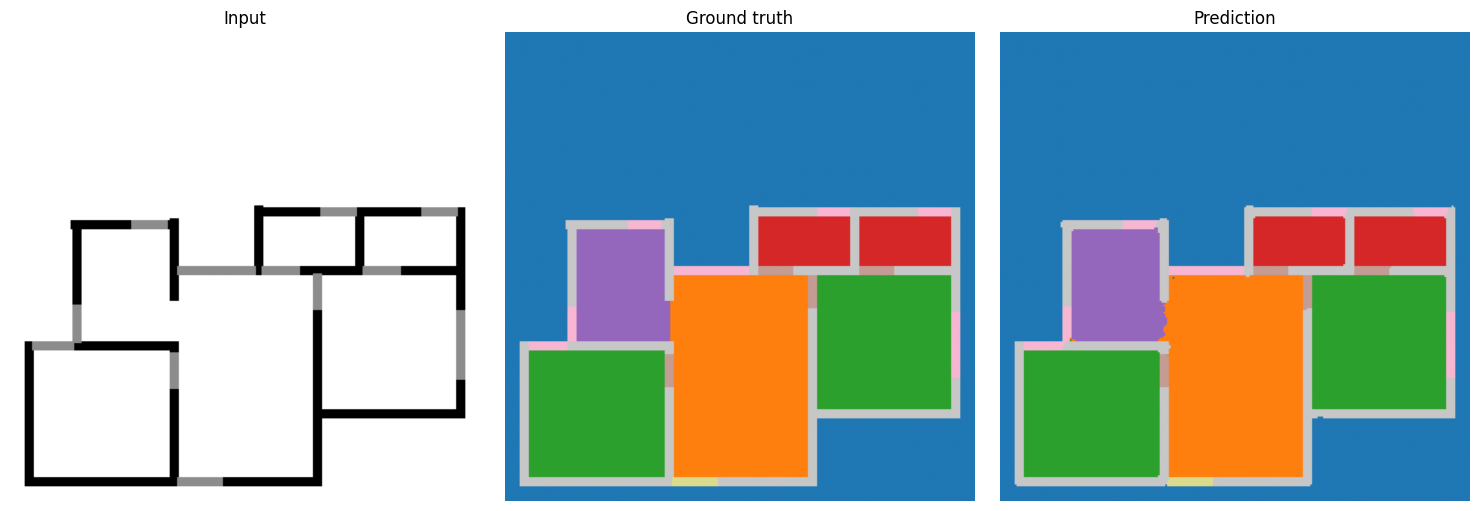

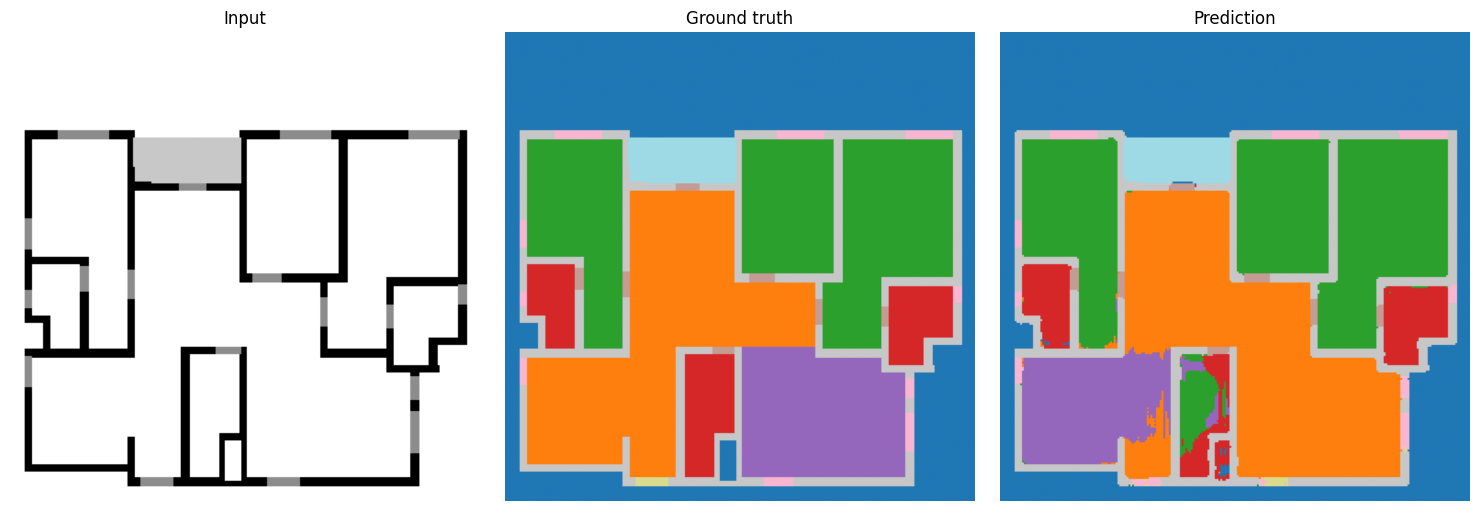

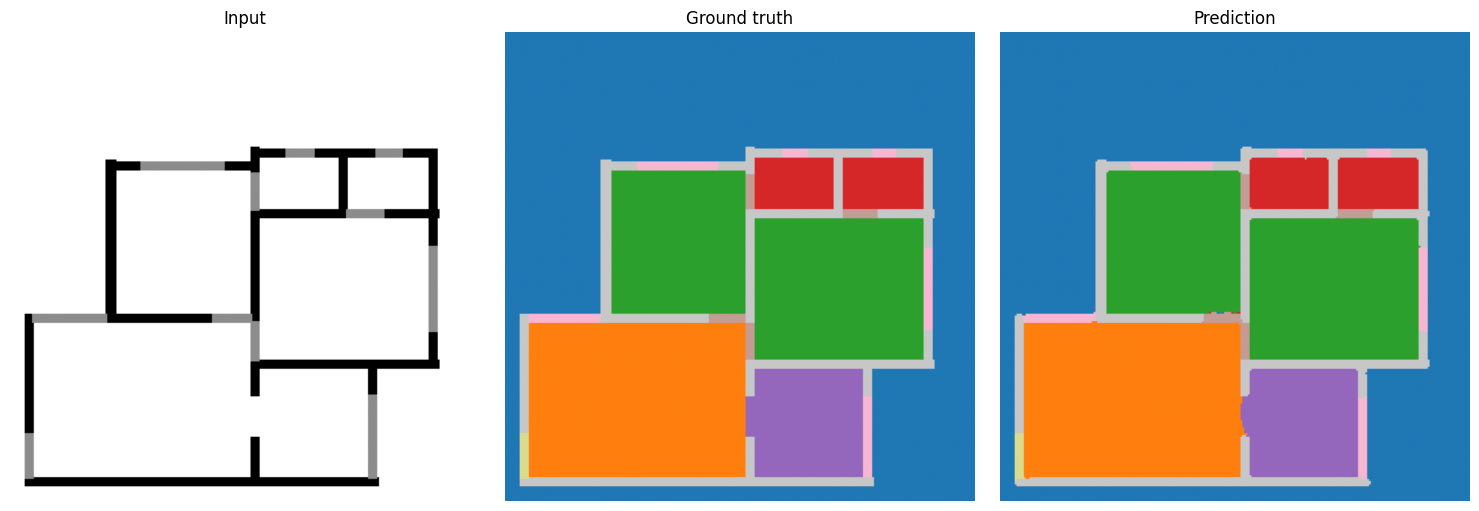

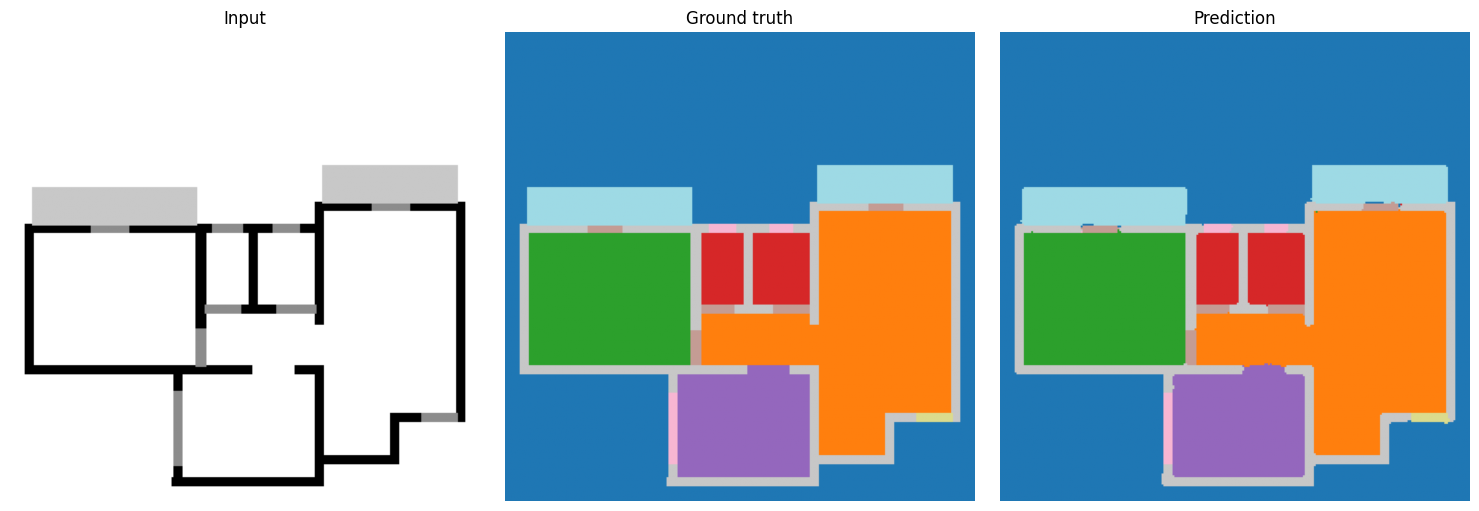

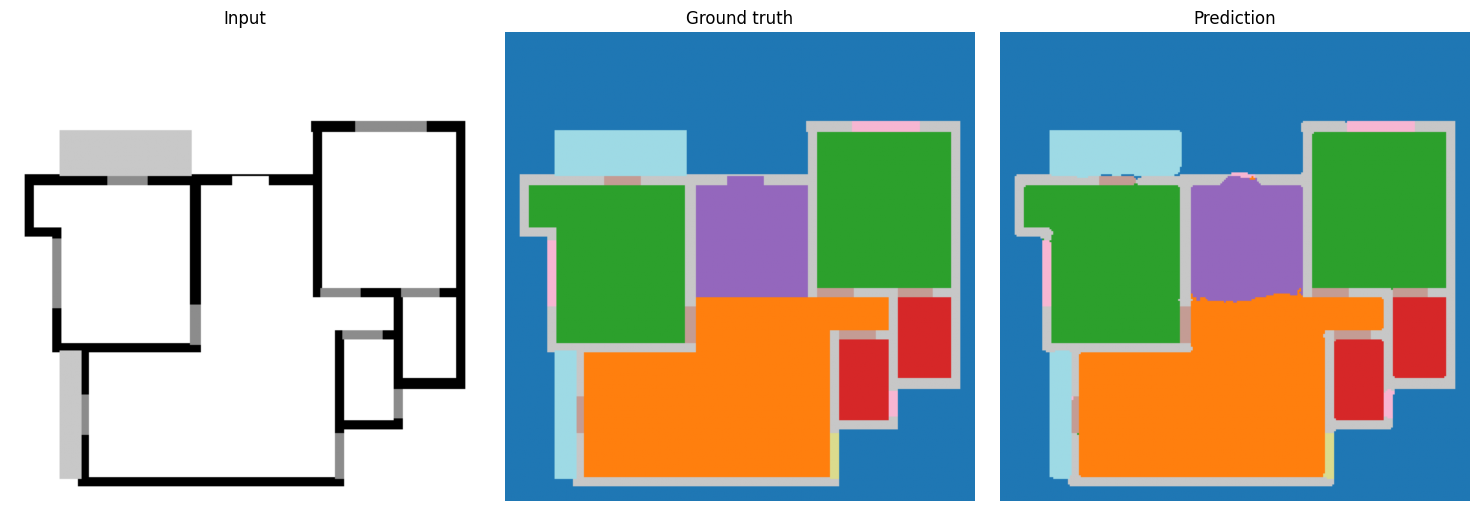

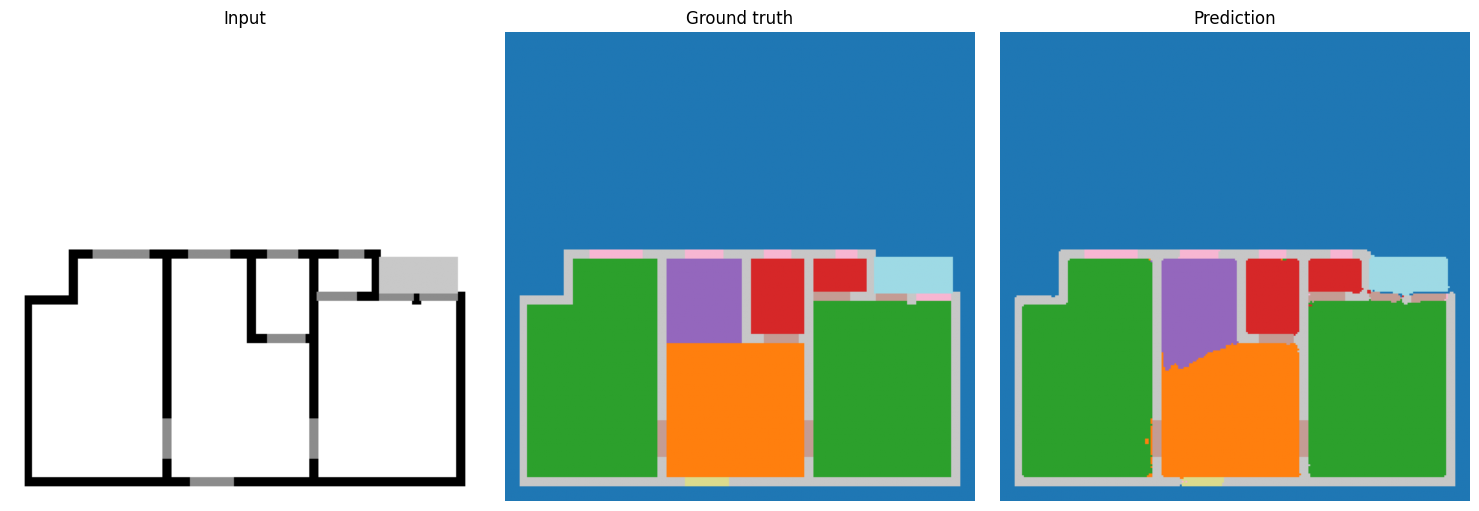

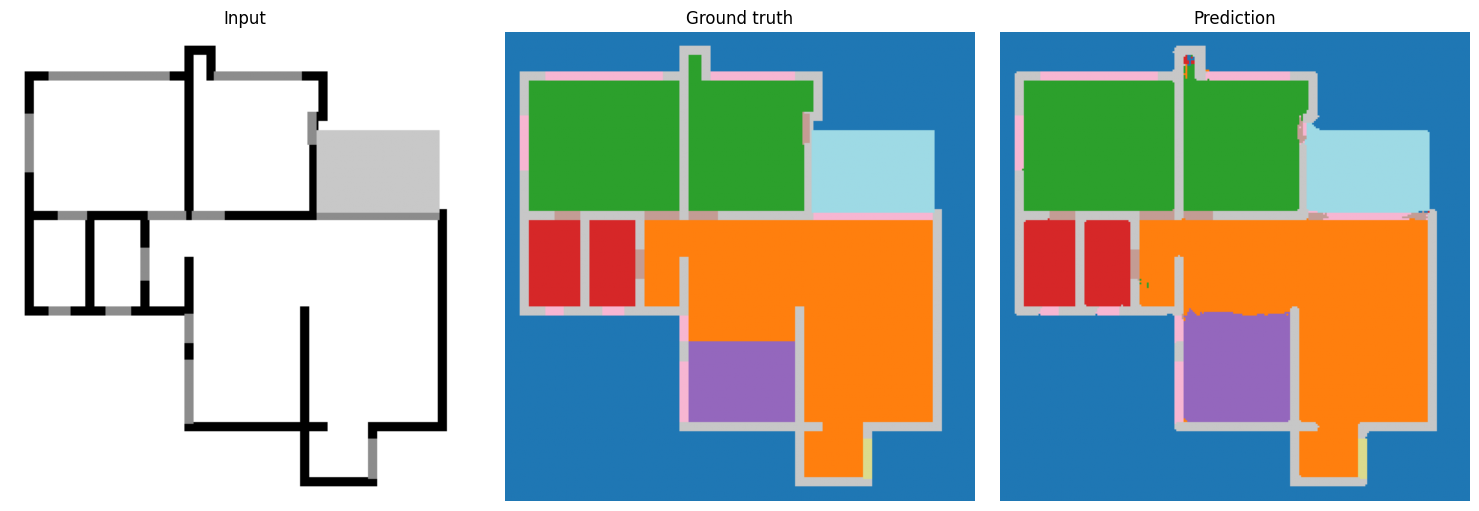

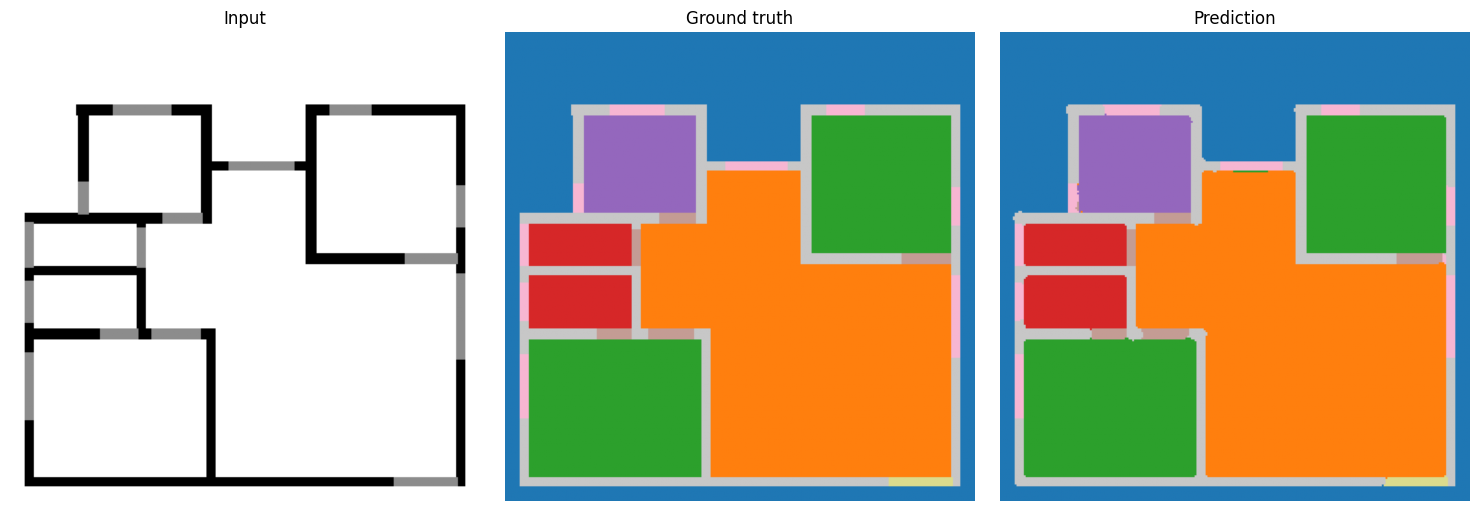

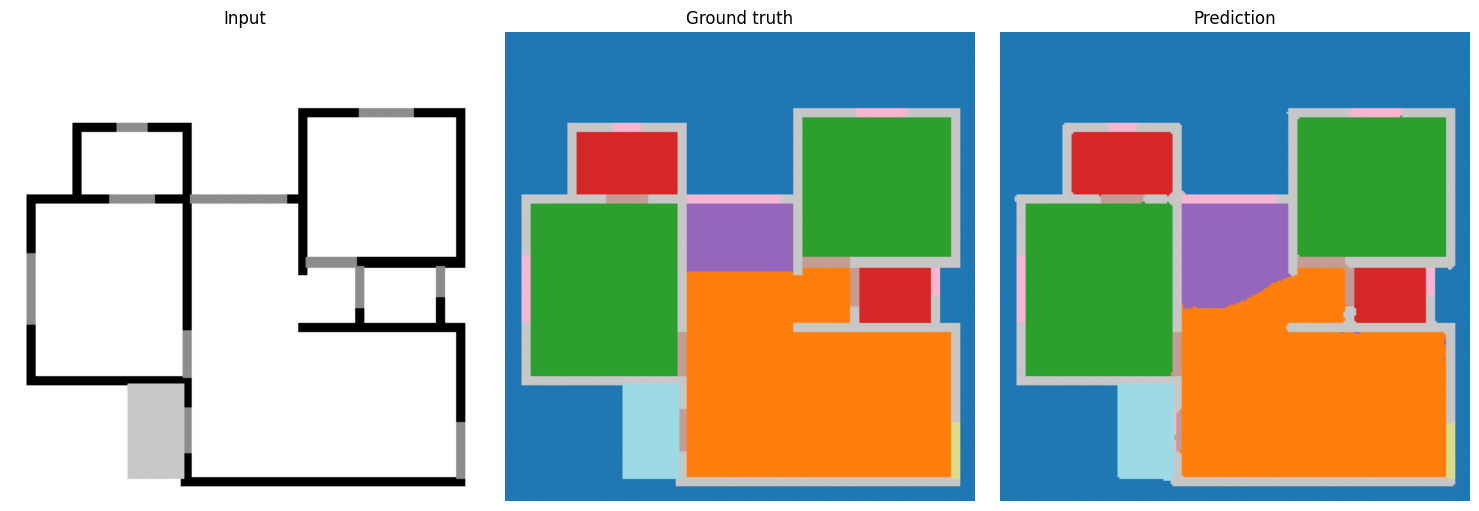

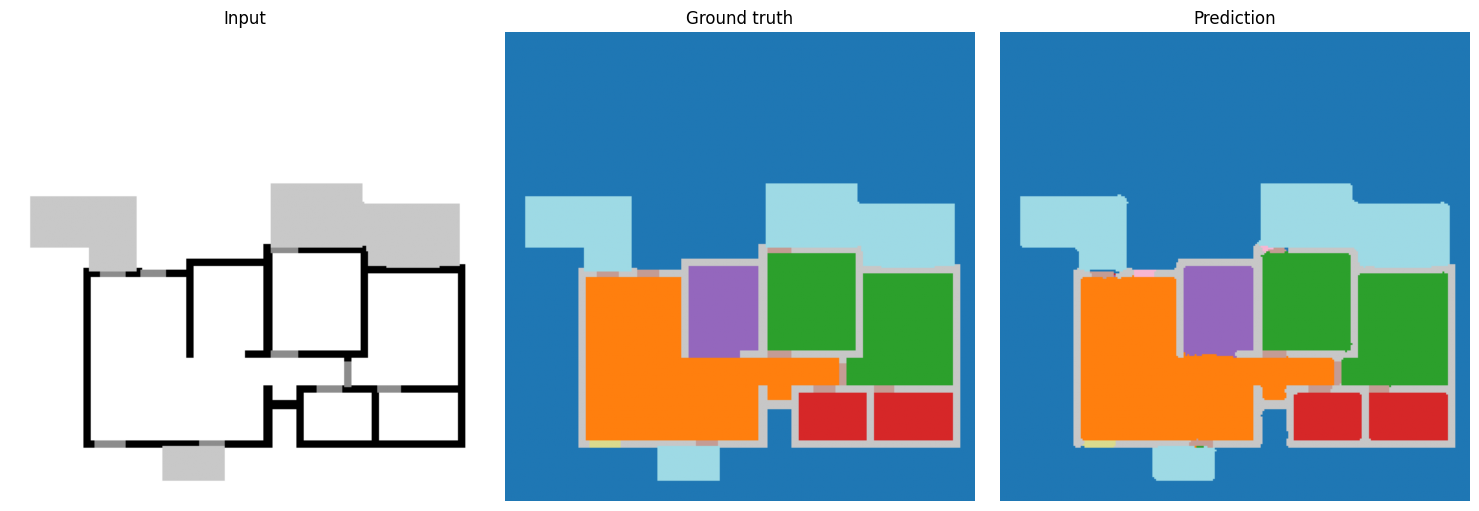

In [10]:
def predict_mask(model, image):
    model.eval()
    image = image.unsqueeze(0)
    image = prepare_images(image)

    with torch.no_grad():
        logits = model(image)
        pred = logits.argmax(dim=1).squeeze(0).cpu()
    return pred


for sample_idx in range(10):
    # sample_idx = 0
    sample_image, sample_mask = valid_dataset[sample_idx]
    pred_mask = predict_mask(model, sample_image)

    cmap = plt.get_cmap("tab20", NUM_CLASSES)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(sample_image.squeeze(0), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")
    axes[1].imshow(sample_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title("Ground truth")
    axes[1].axis("off")
    axes[2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
    axes[2].set_title("Prediction")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()
